In [147]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [148]:
# Load All Titanic Datasets

train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")
submission_df = pd.read_csv("/content/gender_submission.csv")

In [149]:
# Display Dataset Shapes

print("Train Dataset Shape :", train_df.shape)
print("Test Dataset Shape :", test_df.shape)
print("Submission Dataset Shape :", submission_df.shape)

Train Dataset Shape : (891, 12)
Test Dataset Shape : (418, 11)
Submission Dataset Shape : (418, 2)


In [150]:
# Display First 5 Rows of Train Dataset

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [151]:
# Display First 5 Rows of Test Dataset

test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [152]:
# Display First 5 Rows of Submission Dataset

submission_df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [153]:
# Dataset Information

train_df.info()

test_df.info()

submission_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass  

In [154]:
# Statistical Summary of Train Dataset

train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [155]:
# Missing Values in Train Dataset

train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [156]:
# Missing Values in Test Dataset

test_df.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [157]:
# Missing Value Percentage in Train Dataset

(train_df.isnull().sum()/len(train_df))*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [158]:
# Missing Value Percentage in Test Dataset

(test_df.isnull().sum()/len(test_df))*100

,0
PassengerId,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234
Cabin,78.229665


In [159]:
# Remove Cabin Column from Train Dataset

train_df.drop("Cabin", axis=1, inplace=True)

In [160]:
# Remove Cabin Column from Test Dataset

test_df.drop("Cabin", axis=1, inplace=True)

In [161]:
# Fill Missing Values in Train Dataset

train_df["Age"].fillna(train_df["Age"].median(), inplace=True)

train_df["Embarked"].fillna(train_df["Embarked"].mode()[0], inplace=True)

/tmp/ipykernel_3518/3465426845.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df["Age"].fillna(train_df["Age"].median(), inplace=True)
/tmp/ipykernel_3518/3465426845.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [162]:
# Fill Missing Values in Test Dataset

test_df["Age"].fillna(test_df["Age"].median(),inplace=True)

test_df["Fare"].fillna(test_df["Fare"].median(),inplace=True)

/tmp/ipykernel_3518/1572194440.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df["Age"].fillna(
/tmp/ipykernel_3518/1572194440.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: va

In [163]:
# Check Duplicate Records

print("Train Duplicates :", train_df.duplicated().sum())
print("Test Duplicates :", test_df.duplicated().sum())

Train Duplicates : 0
Test Duplicates : 0


In [164]:
# Verify Data Cleaning Results

print(train_df.isnull().sum())
print()
print(test_df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [181]:
# Verify Dataset Shape After Cleaning

print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape : (891, 12)
Test Shape : (418, 10)


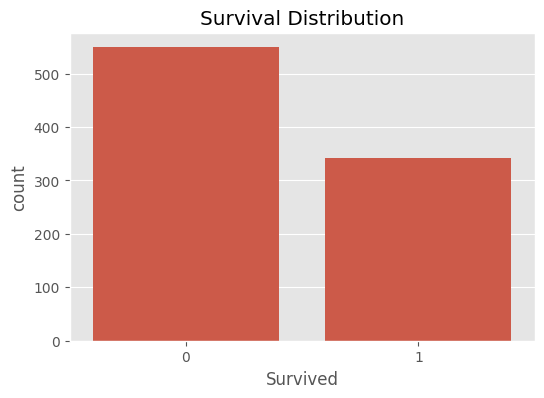

In [165]:
# Survival Distribution Analysis

plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=train_df)

plt.title("Survival Distribution")
plt.show()

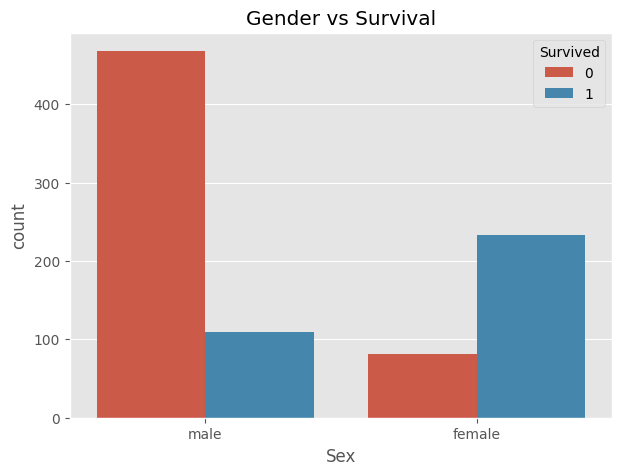

In [166]:
# Gender Wise Survival Analysis

plt.figure(figsize=(7,5))

sns.countplot(x="Sex",hue="Survived", data=train_df)

plt.title("Gender vs Survival")
plt.show()

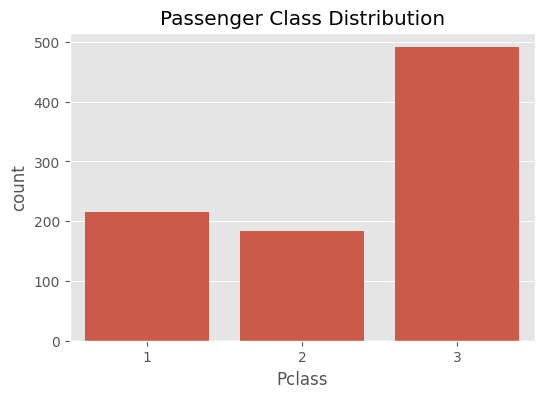

In [167]:
# Passenger Class Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Pclass",data=train_df)

plt.title("Passenger Class Distribution")
plt.show()

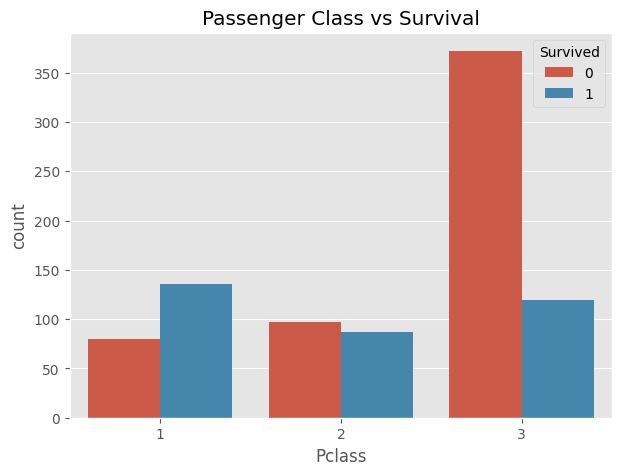

In [168]:
# Passenger Class vs Survival

plt.figure(figsize=(7,5))

sns.countplot(x="Pclass",hue="Survived",data=train_df)

plt.title("Passenger Class vs Survival")
plt.show()

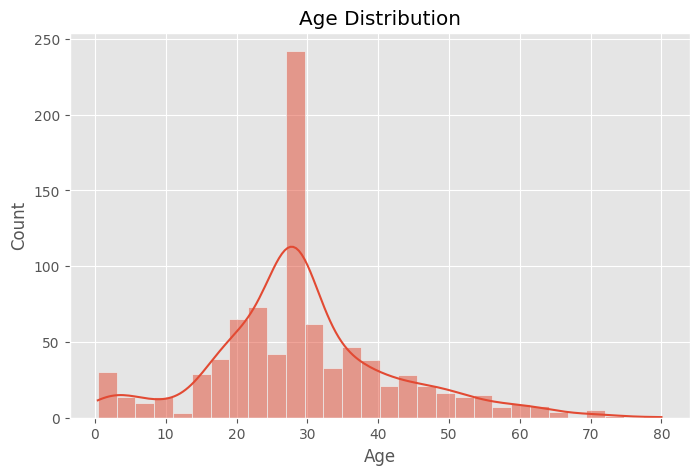

In [169]:
# Age Distribution Analysis

plt.figure(figsize=(8,5))

sns.histplot(train_df["Age"],bins=30,kde=True)

plt.title("Age Distribution")
plt.show()

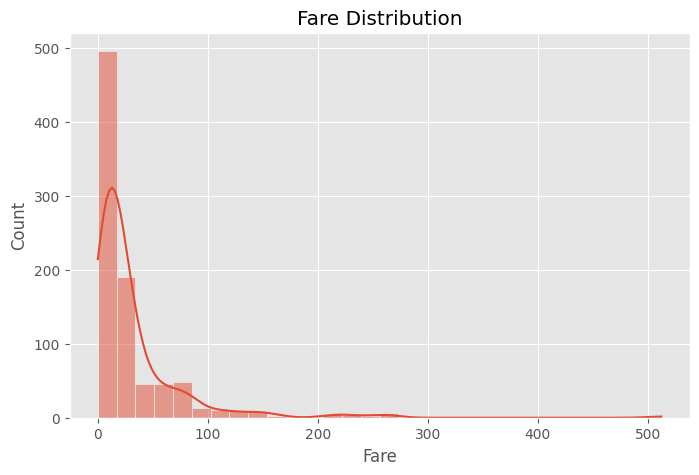

In [170]:
# Fare Distribution Analysis

plt.figure(figsize=(8,5))

sns.histplot(train_df["Fare"],bins=30,kde=True)

plt.title("Fare Distribution")
plt.show()

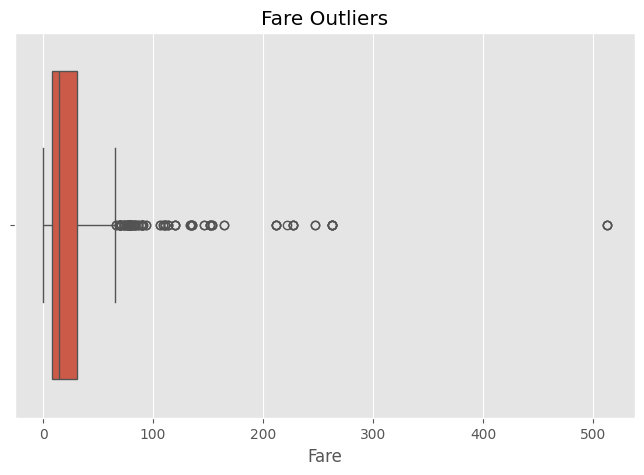

In [171]:
# Fare Outlier Detection

plt.figure(figsize=(8,5))

sns.boxplot(x=train_df["Fare"])

plt.title("Fare Outliers")
plt.show()

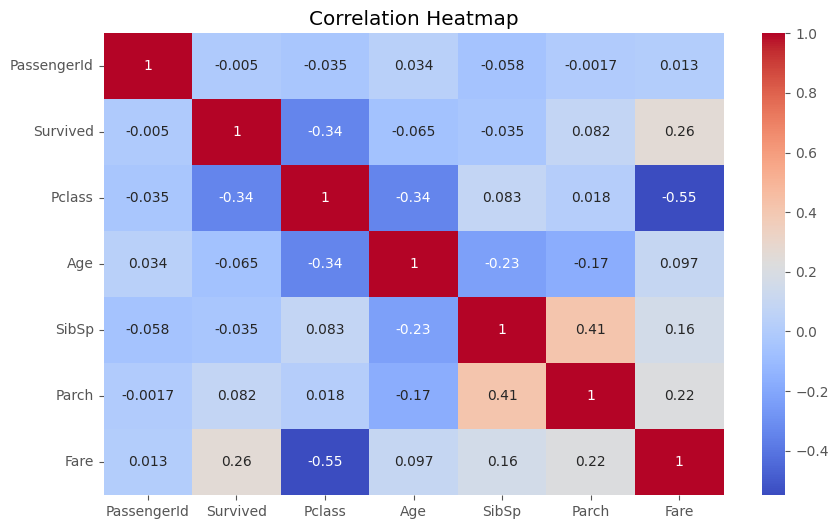

In [172]:
# Correlation Heatmap

numeric_df = train_df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

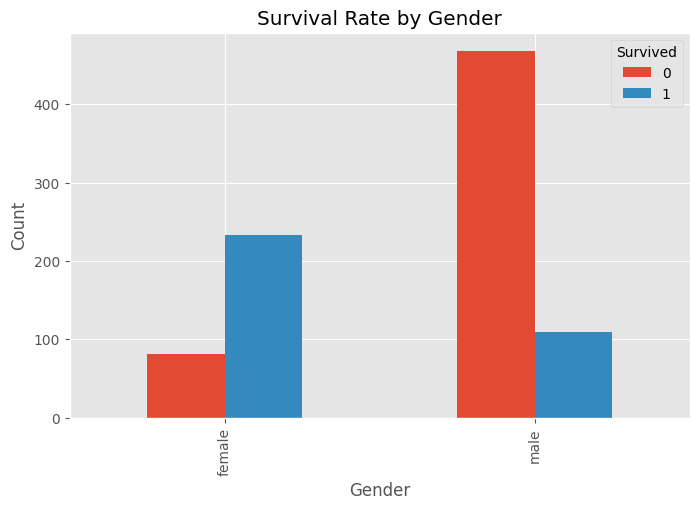

In [182]:
# Survival Rate by Gender

survival_gender = pd.crosstab(
    train_df["Sex"],
    train_df["Survived"]
)

survival_gender.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

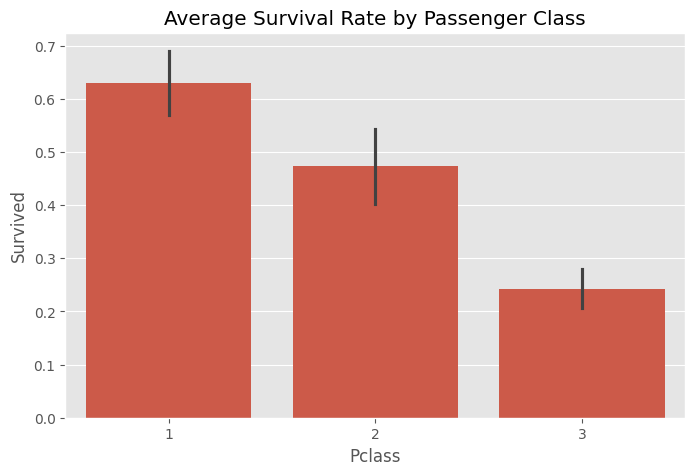

In [184]:
# Average Survival Rate by Passenger Class

plt.figure(figsize=(8,5))

sns.barplot(
    x="Pclass",
    y="Survived",
    data=train_df
)

plt.title(
    "Average Survival Rate by Passenger Class"
)

plt.show()

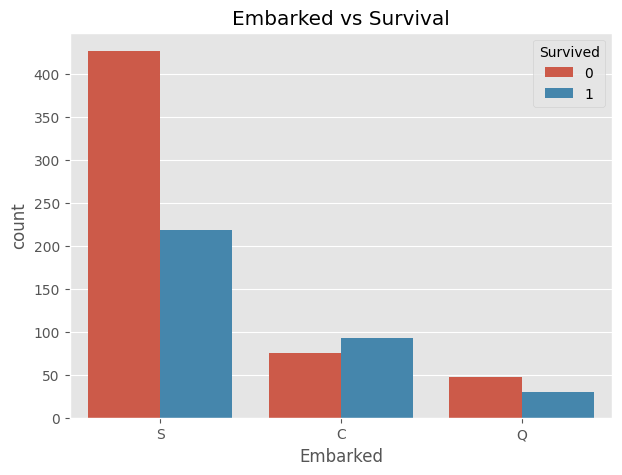

In [173]:
# Embarked Port vs Survival Analysis

plt.figure(figsize=(7,5))

sns.countplot(x="Embarked",hue="Survived",data=train_df)

plt.title("Embarked vs Survival")
plt.show()

In [174]:
# Create Family Size Feature

train_df["FamilySize"] = (train_df["SibSp"] + train_df["Parch"] + 1)

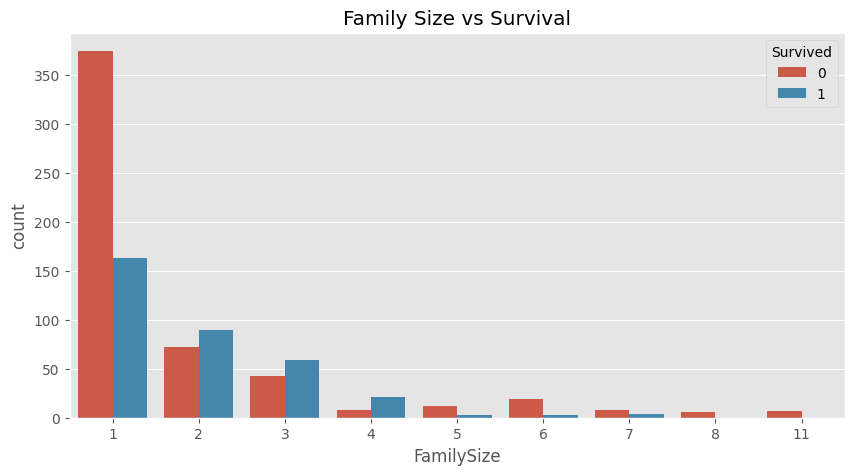

In [175]:
# Family Size vs Survival

plt.figure(figsize=(10,5))

sns.countplot(x="FamilySize", hue="Survived", data=train_df)

plt.title("Family Size vs Survival")
plt.show()

In [185]:
# Family Size Statistics

train_df["FamilySize"].describe()

,FamilySize
count,891.000000
mean,1.904602
std,1.613459
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,11.000000


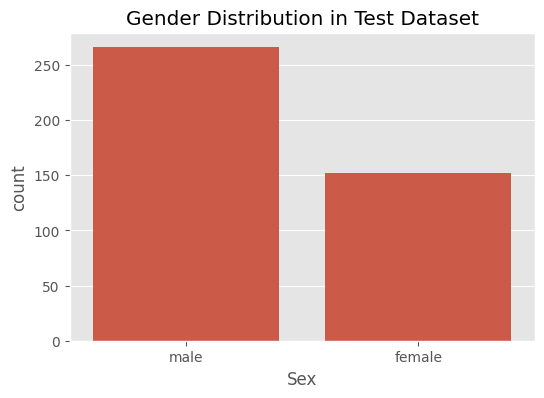

In [176]:
# Test Dataset Gender Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=test_df)

plt.title("Gender Distribution in Test Dataset")
plt.show()

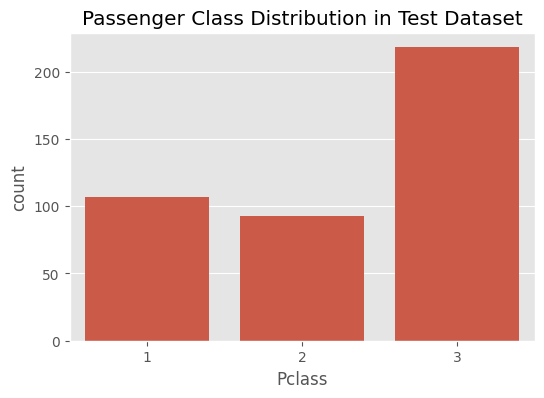

In [177]:
# Test Dataset Passenger Class Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=test_df)

plt.title("Passenger Class Distribution in Test Dataset")
plt.show()

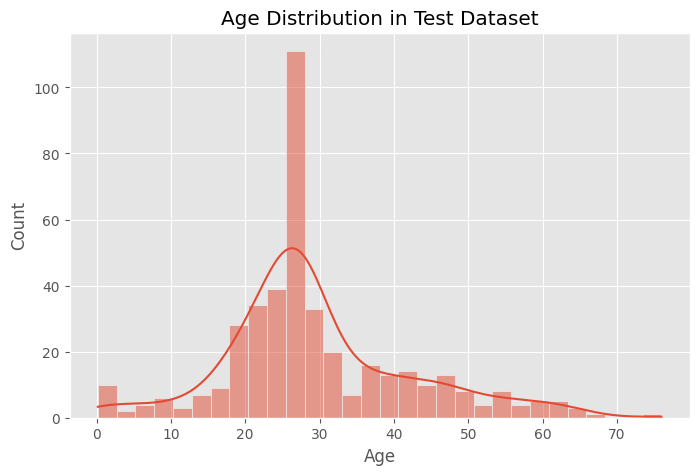

In [178]:
# Test Dataset Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(test_df["Age"], bins=30, kde=True)

plt.title("Age Distribution in Test Dataset")
plt.show()

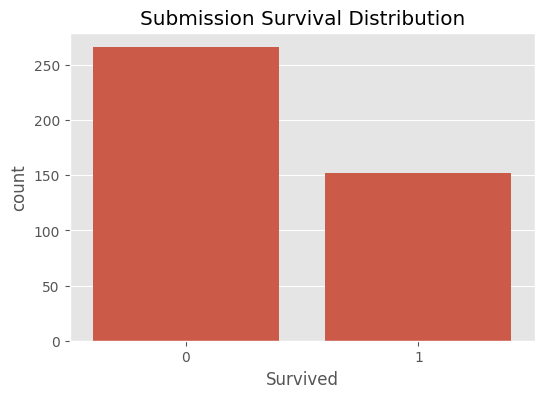

In [179]:

# Submission Dataset Survival Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=submission_df)

plt.title("Submission Survival Distribution")
plt.show()

In [180]:
# Dataset Comparison Table

comparison = pd.DataFrame({
    "Dataset":["Train","Test","Submission"],
    "Rows":[
        train_df.shape[0],
        test_df.shape[0],
        submission_df.shape[0]
    ],
    "Columns":[
        train_df.shape[1],
        test_df.shape[1],
        submission_df.shape[1]
    ]
})

comparison

,Dataset,Rows,Columns
0,Train,891,12
1,Test,418,10
2,Submission,418,2


In [186]:
# Compare Missing Values After Cleaning

missing_compare = pd.DataFrame({
    "Train": train_df.isnull().sum(),
    "Test": test_df.isnull().sum()
})

missing_compare

,Train,Test
Age,0,0.0
Embarked,0,0.0
FamilySize,0,NaN
Fare,0,0.0
Name,0,0.0
Parch,0,0.0
PassengerId,0,0.0
Pclass,0,0.0
Sex,0,0.0
SibSp,0,0.0


In [187]:
# Survival Percentage

survival_percentage = (
    train_df["Survived"]
    .value_counts(normalize=True)
    * 100
)

print(survival_percentage)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


# ==========================================
# Key Insights
# ==========================================

1. Female passengers had a higher survival rate.
2. First-class passengers had the highest survival rate.
3. Most passengers belonged to the age group 20-40.
4. Higher fare passengers showed better survival chances.
5. Third-class passengers had the lowest survival rate.
6. Missing values were successfully handled.
7. Train, Test and Submission datasets were analyzed.


# ==========================================
# Conclusion
# ==========================================


The Titanic datasets were successfully cleaned and analyzed.
Data cleaning techniques such as handling missing values,
removing unnecessary columns and duplicate records were applied.
EDA revealed important patterns related to survival,
gender, passenger class, age and fare.
